# ch223 — Numerical Integration

Most integrals do not have closed-form solutions. Numerical methods compute them to arbitrary precision using nothing but function evaluations.

This chapter covers three classical rules — Riemann, Trapezoid, Simpson — and connects them to the approximation trade-offs from ch220.

Exact integral (scipy.quad): 0.886207348259521


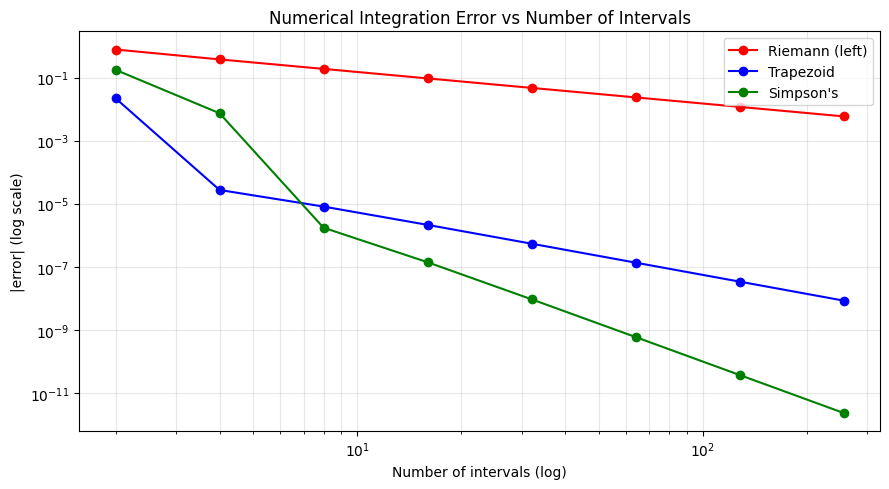


Convergence rates (expected: Riemann O(h), Trapezoid O(h^2), Simpson O(h^4)):
  Riemann (left): halving n reduces error by 2^1.0
  Trapezoid: halving n reduces error by 2^2.0
  Simpson's: halving n reduces error by 2^4.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Test function: f(x) = exp(-x^2) (Gaussian, no closed-form antiderivative)
f = lambda x: np.exp(-x**2)
a, b = 0, 3
exact, _ = quad(f, a, b)
print(f"Exact integral (scipy.quad): {exact:.15f}")

def riemann_left(f, a, b, n):
    x = np.linspace(a, b, n+1)
    return np.sum(f(x[:-1])) * (b - a) / n

def trapezoid(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    return np.trapezoid(y, x)

def simpsons(f, a, b, n):
    # n must be even
    if n % 2: n += 1
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return h/3 * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])

n_vals = [2, 4, 8, 16, 32, 64, 128, 256]
methods = {'Riemann (left)': riemann_left, 'Trapezoid': trapezoid, "Simpson's": simpsons}
colors = ['red', 'blue', 'green']

fig, ax = plt.subplots(figsize=(9, 5))
for (name, method), color in zip(methods.items(), colors):
    errors = [abs(method(f, a, b, n) - exact) for n in n_vals]
    ax.loglog(n_vals, errors, 'o-', color=color, label=name)

ax.set_xlabel('Number of intervals (log)'); ax.set_ylabel('|error| (log scale)')
ax.set_title('Numerical Integration Error vs Number of Intervals')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch223_methods.png', dpi=100); plt.show()

# Print convergence rates
print("\nConvergence rates (expected: Riemann O(h), Trapezoid O(h^2), Simpson O(h^4)):")
for name, method in methods.items():
    e1 = abs(method(f, a, b, 64) - exact)
    e2 = abs(method(f, a, b, 128) - exact)
    if e1 > 1e-15 and e2 > 1e-15:
        rate = np.log2(e1 / e2)
        print(f"  {name}: halving n reduces error by 2^{rate:.1f}")


## Gaussian Quadrature

Instead of evenly-spaced points, choose the evaluation points **optimally**. Gauss-Legendre quadrature with N points is exact for polynomials of degree 2N-1. For smooth functions, it converges far faster than Riemann sums.

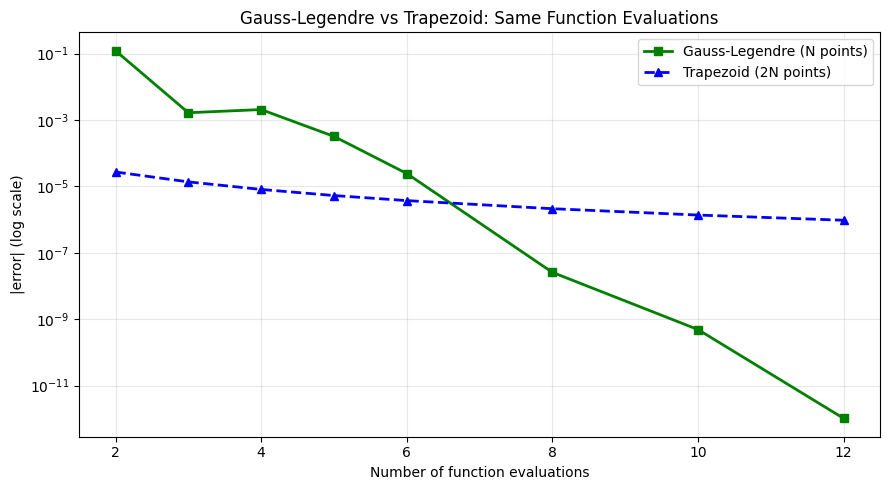

Gauss-Legendre with 10 pts: error = 4.86e-10
Trapezoid with 20 pts:      error = -1.37e-06


In [3]:
from numpy.polynomial.legendre import leggauss

def gauss_legendre(f, a, b, n):
    # Get Gauss points and weights on [-1, 1], transform to [a, b]
    xi, wi = leggauss(n)
    # Transform: x = (b-a)/2 * xi + (a+b)/2
    x_mapped = 0.5*(b - a)*xi + 0.5*(b + a)
    return 0.5*(b - a) * np.sum(wi * f(x_mapped))

n_pts = [2, 3, 4, 5, 6, 8, 10, 12]
gl_errors = [abs(gauss_legendre(f, a, b, n) - exact) for n in n_pts]
trap_errors = [abs(trapezoid(f, a, b, n*2) - exact) for n in n_pts]  # same function evals

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(n_pts, gl_errors, 'gs-', lw=2, label='Gauss-Legendre (N points)')
ax.semilogy(n_pts, trap_errors, 'b^--', lw=2, label='Trapezoid (2N points)')
ax.set_xlabel('Number of function evaluations')
ax.set_ylabel('|error| (log scale)')
ax.set_title('Gauss-Legendre vs Trapezoid: Same Function Evaluations')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch223_gauss.png', dpi=100); plt.show()
print(f"Gauss-Legendre with 10 pts: error = {gauss_legendre(f, a, b, 10) - exact:.2e}")
print(f"Trapezoid with 20 pts:      error = {trapezoid(f, a, b, 20) - exact:.2e}")


## Adaptive Integration

Scipy's `quad` uses **adaptive** quadrature: it allocates more evaluation points where the function varies rapidly, fewer where it is smooth. This is why it handles difficult integrands with minimal function calls.

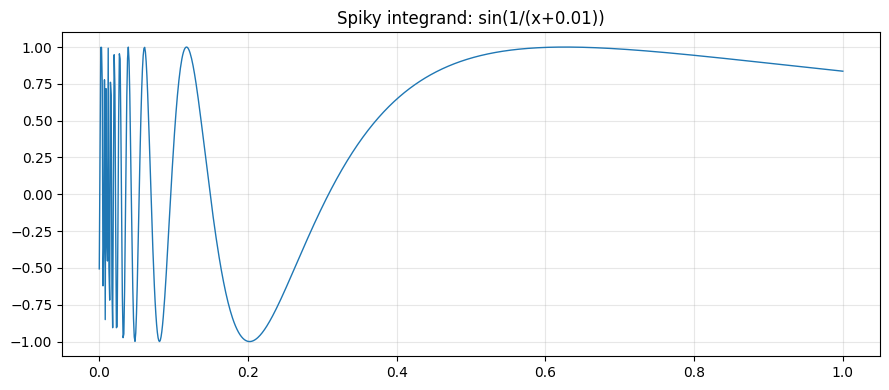

Trapezoid (10000 pts): 0.51237693
Adaptive quad:              0.51236963  (est error=1.14e-08)
Adaptive used 483 function evaluations vs 10000


In [4]:
# Demonstrate adaptive behaviour on a spiky function
f_spiky = lambda x: np.sin(1 / (x + 0.01)) if x > -0.01 else 0  # rapid oscillation near 0
f_spiky_v = np.vectorize(f_spiky)

x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_spiky_v(x_plot), lw=1)
plt.title('Spiky integrand: sin(1/(x+0.01))'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch223_spiky.png', dpi=100); plt.show()

# Compare fixed-grid vs adaptive
n_pts_trap = 10000
trap_val = trapezoid(f_spiky_v, 0, 1, n_pts_trap)
adaptive_val, adaptive_err, info = quad(f_spiky_v, 0, 1, full_output=True)
print(f"Trapezoid ({n_pts_trap} pts): {trap_val:.8f}")
print(f"Adaptive quad:              {adaptive_val:.8f}  (est error={adaptive_err:.2e})")
print(f"Adaptive used {info['neval']} function evaluations vs {n_pts_trap}")


## Summary

| Method | Error order | Notes |
|---|---|---|
| Left Riemann | O(h) | Lowest accuracy |
| Trapezoid | O(h^2) | Simple, reliable |
| Simpson's | O(h^4) | Requires even n, excellent for smooth f |
| Gauss-Legendre | Exponential | Optimal node placement |
| Adaptive | Problem-dependent | Best for production use |

**Forward reference:** ch224 — Monte Carlo Integration takes a completely different approach — randomness instead of quadrature — and scales well to high-dimensional integrals.